# Lab IX - Mozaicare/Demozaicare

## 1. Senzori de imagine si filtre de culoare (Color Filter Array)

Un senzor de imagine reprezinta un dispozitiv care converteste o imagine optica intr-un semnal electric.

Filtrele de culoare sunt dispozitive necesare senzorilor de imagine pentru a capta informația de culoare. Senzorii de imagine nu dispun natural de capacitatea de a distinge diferite lungimi de undă, aceștia fiind sensibili doar în intensitate;

După achiziție, imaginile sunt interpolate pentru fiecare plan de culoare.

Filtrele de culoare  de tip CFA (Color Filter Array) sau CFM (Color Filter Mosaic) sunt filtre rectangulare dispuse pe suprafața fotocelulelor unui senzor sub forma unui mozaic;
      
<img src="Ex_Filtre1.jpg"><center>Ex de filtre</center> 

## 2. Demozaicare

In cazul filtrelor de culoare de tip mozaic, imaginea achiziționată trebuie reconstruită prin refacerea eșantioanelor de culoare incomplete, proces numit demozaicare. Acesta poate fi efectuat de către hardware sau poate fi lăsat la îndemâna utilizatorului (format RAW).

<img src="Demozaicare.jpg"><center>Demozaicarea</center>

Demozaicarea este deci procesul de refacere a valorilor complete (R, G, B) in fiecare pixel, pornind de la valorile partiale de R, G, B inregistrate pe senzor conform matricii CFA (de obicei Bayer). Acest proces este evident o interpolare a valorilor lipsa in functie de valorile inregistrate.

## Exercitiul 1: Mozaicarea
Implementati o functie care sa transforme o imagine RGB intr-o imaginea mozaic de tip Bayer.

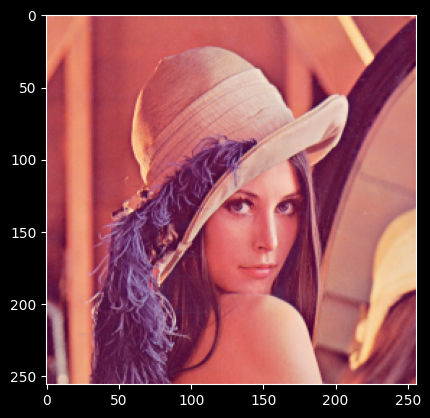

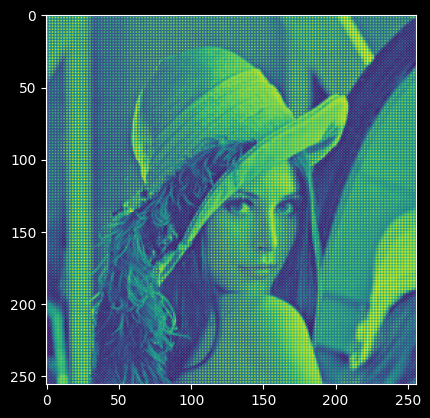

(<Figure size 640x480 with 1 Axes>,
 None)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io,color

plt.style.use('dark_background')

def rgb2bayer(img):
    # se returneaza o matrice cu aceleasi dimensiuni ca ale lui img
    L,C,_ = np.shape(img)
    imgout = np.zeros((L,C))
    #window = np.ndarray[[[1,0,0],[0,1,0]],[[0,1,0],[0,0,1]]]
    for l in range(0,L):
        for c in range(0,C):
            if (l%2==0 and c%2==0):
                imgout[l,c] = img[l,c,0]
            elif (l%2==1 and c%2==1):
                imgout[l,c] = img[l,c,2]
            else:
                imgout[l,c] = img[l,c,1]
    return imgout

img = io.imread('../lenamic.png')
plt.figure(), plt.imshow(img), plt.show()

imgout = rgb2bayer(img)
plt.figure(), plt.imshow(imgout), plt.show()

### Exercițiul 2. Demozaicare 1
Realizati o functie care sa implementeze demozaicarea unei imagini inregistrate conform CFA Bayer dupa o procedura de interpolare de ordin 0 (valoarea in punctul necunoscut este valoare in cel mai apropiat vecin cunoscut.

Vom considera ca in caz de egalitate a distantelor in plan intre pixeli, cel mai apropiat vecin este cel de la stanga si de sus.

Masurati calitatea imaginii demozaicate fata de imaginea de referinta RGB.

In [8]:
# bordez imaginea
# aplic demozaicarea conform CFA
def demozaic0(mozaic):
    # if (np.max(img)>1):
    #     img = img/255.0
        
    L,C = np.shape(mozaic)
    img_bordat = np.zeros((L+1,C+1))
    img_bordat[1:L+1,1:C+1] = mozaic[:,:]
    img_bordat[0,1:C+1]     = mozaic[1,:]
    img_bordat[1:L+1,0]     = mozaic[:,1]
    img_bordat[0,0]         = mozaic[1,1]
     
    rgb = np.zeros((L,C,3))

    # for l in range(0,L):
    #     for c in range(0,C):
    #         if (l%2==0 and c%2==0): # R
    #             rgb[l,c,0] = img_bordat[l,c]
    #             rgb[l,c,1] = img_bordat[l-1,c]
    #             rgb[l,c,2] = img_bordat[l-1,c-1]
    #         elif (l%2==1 and c%2==1): # B
    #             rgb[l,c,0] = img_bordat[l-1,c-1]
    #             rgb[l,c,1] = img_bordat[l-1,c]
    #             rgb[l,c,2] = img_bordat[l-1,c-1]
    #         else: # G
    #             rgb[l,c,0] = img_bordat[l-1,c]
    #             rgb[l,c,1] = img_bordat[l,c]
    #             rgb[l,c,2] = img_bordat[l,c-1]
    # return rgb

    for l in range(1,L):
        for c in range(1,C):
            if (l%2==0):
                if (c%2==0):
                    rgb[l,c,0]=mozaic[l,c]
                    rgb[l,c,1]=mozaic[l-1,c]
                    rgb[l,c,2]=mozaic[l-1,c-1]
                else:
                    rgb[l,c,0]=mozaic[l,c-1]
                    rgb[l,c,1]=mozaic[l,c]
                    rgb[l,c,2]=mozaic[l-1,c]
            else:
                if (c%2==0):
                    rgb[l,c,0]=mozaic[l-1,c]
                    rgb[l,c,1]=mozaic[l,c]
                    rgb[l,c,2]=mozaic[l,c-1]
                else:
                    rgb[l,c,0]=mozaic[l-1,c-1]
                    rgb[l,c,1]=mozaic[l-1,c]
                    rgb[l,c,2]=mozaic[l,c]
    return rgb

######### !!! redo this at home !!! #########


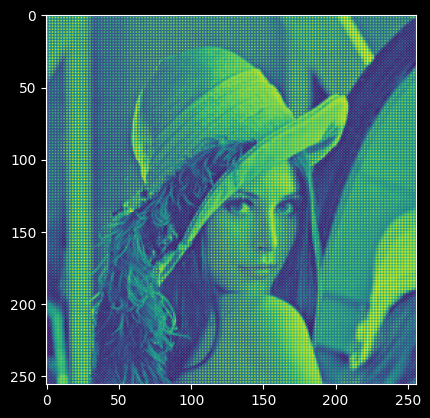

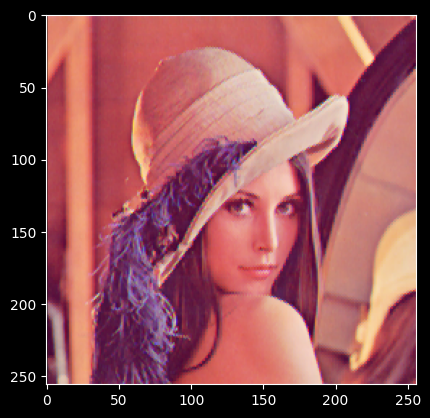

(<Figure size 640x480 with 1 Axes>,
 None)

In [9]:
img_mozaicare = rgb2bayer(img)
plt.figure(), plt.imshow(img_mozaicare), plt.show()

img_demozaic0 = demozaic0(img_mozaicare)
plt.figure(), plt.imshow(np.uint8(img_demozaic0)), plt.show()

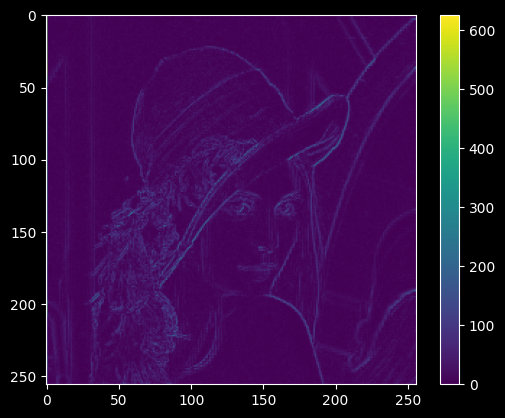

(<Figure size 640x480 with 2 Axes>,
 None)

In [10]:
## facem o imegine de diferenta
# trecem la float ca sa nu se dea peste cap la diferenta (pt uint8)
diff = np.float64(img_demozaic0) - np.float64(img[:,:,0:3])
## SAU
#diff = img/255.0 - x/255.0

# diferenta cumulata
diffcum = np.sum(np.abs(diff), axis = 2)
plt.figure(), plt.imshow(diffcum), plt.colorbar(), plt.show()

### Exercițiul 2. Demozaicare 2
Realizati o functie care sa implementeze demozaicarea unei imagini inregistrate conform CFA Bayer dupa o procedura de interpolare biliniara (fiecare noua valoare este media celor 4 (sau 3) vecini).

Masurati calitatea imaginii demozaicate fata de imaginea de referinta RGB.

In [ ]:
# interpolare biliniara ## TEMA ## (din slideurile de curs)
# refacere img mozaicata cu fiecare demozaicare si masurat calitate

def demozaic_biliniar(mozaic):
    # if (np.max(img)>1):
    #     img = img/255.0
        
    L,C = np.shape(mozaic)
    rgb = np.zeros((L,C,3))

    for l in range(1,L):
        for c in range(1,C):     
            if (l==0):
                if (c%2==1):
                    rgb[l,c,1] = (mozaic[l-1,c] + mozaic[l+1,c] + mozaic[l,c+1]) // 3
            elif (l==L-1):
                if (c%2==1):
                    rgb[l,c,1] = (mozaic[l-1,c] + mozaic[l+1,c] + mozaic[l,c-1]) // 3
            elif (c==0):
                if (l%2==1):
                    rgb[l,c,1] = (mozaic[l,c-1] + mozaic[l,c+1] + mozaic[l+1,c]) // 3
            elif (c==C-1):
                if (l%2==1):
                    rgb[l,c,1] = (mozaic[l,c-1] + mozaic[l,c+1] + mozaic[l-1,c]) // 3
            elif (c!=0 and c!=C-1 and l!=0 and l!=L-1):
                if (l%2==1 and c%2==1) or (l%2==0 and c%2==0):
                    rgb[l,c,1] = (mozaic[l-1,c] + mozaic[l+1,c] + mozaic[l,c-1] + mozaic[l,c+1]) // 4 #### Green
            
            
            
    return rgb

### Exercițiul 3. Demozaicare 3
Realizati o functie care sa implementeze demozaicarea unei imagini inregistrate conform CFA Bayer dupa o procedura de interpolare bazata pe gradientii orizontali si verticali.
Astfel, daca gradientul vertical in jurul punctului curent este cel mai important, atunci interpolarea se face doar pe orizontala; daca gradientul orizontal in jurul punctului curent este cel mai important, atunci interpolarea se face doar pe verticala; altfel,interpolarea este biliniara.

Masurati calitatea imaginii demozaicate fata de imaginea de referinta RGB.

In [ ]:
# interpolare cu gradienti ## TEMA ## (din slideurile de curs)
